# 04 - Feature Engineering

**Objective:** Create new performance features based on insights from EDA (notebook 02) and Hypothesis Testing (notebook 03).

**Key insights that informed our feature choices:**
1. **Hypothesis 1 (Ball Control):** Teams with higher assist-to-turnover ratios win more -> `assist_turnover_ratio`
2. **Hypothesis 3 (Home Advantage):** Significant home court advantage exists -> `home_win_pct`, `away_win_pct`, `home_advantage`
3. **EDA Correlations:** Scoring and defensive metrics relate to winning -> `point_diff`, `scoring_efficiency`, `defensive_pressure`
4. **Conference Performance:** Conference record matters -> `conf_win_pct`

**Input:** `data/processed/cleaned_basketball_data.csv` (from notebook 01)
**Output:** Updated `data/processed/cleaned_basketball_data.csv` (with engineered features)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv("../data/processed/cleaned_basketball_data.csv")
print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nExisting columns: {list(df.columns)}")

Loaded cleaned dataset: 10,000 rows x 37 columns

Existing columns: ['id', 'year', 'rank', 'school', 'games', 'wins', 'losses', 'win_percentage', 'conference_wins', 'conference_losses', 'home_wins', 'home_losses', 'away_wins', 'away_losses', 'offensive_rating', 'defensive_rating', 'net_rating', 'field_goals', 'field_goal_attempts', 'field_goal_percentage', '3_pointers', '3_pointer_attempts', '3_pointer_percentage', 'effective_field_goal_percentage', 'free_throws', 'free_throw_attempts', 'free_throw_percentage', 'offensive_rebounds', 'total_rebounds', 'assists', 'steals', 'blocks', 'turnovers', 'personal_fouls', 'points', 'opponent_points', 'simple_rating']


## 2. Engineer New Features

Based on our EDA and hypothesis testing findings, we create the following features:

| Feature | Formula | Rationale |
|---------|---------|----------|
| `point_diff` | points - opponent_points | Direct measure of game margin |
| `assist_turnover_ratio` | assists / turnovers | Ball control indicator (Hypothesis 1) |
| `home_win_pct` | home_wins / (home_wins + home_losses) | Home performance (Hypothesis 3) |
| `away_win_pct` | away_wins / (away_wins + away_losses) | Away performance (Hypothesis 3) |
| `home_advantage` | home_win_pct - away_win_pct | Net home court effect |
| `conf_win_pct` | conf_wins / (conf_wins + conf_losses) | Conference competitiveness |
| `scoring_efficiency` | points / field_goal_attempts | Offensive efficiency |
| `defensive_pressure` | steals + blocks | Defensive disruption |


In [3]:
# create new features with safe division (avoid division by zero)

# 1. Point differential - direct margin of victory/defeat
df['point_diff'] = df['points'] - df['opponent_points']

# 2. Assist-to-turnover ratio - ball control (supported by Hypothesis 1)
df['assist_turnover_ratio'] = np.where(
    df['turnovers'] == 0, 0, df['assists'] / df['turnovers']
)

# 3-5. Home/Away/Advantage metrics (supported by Hypothesis 3)
df['home_win_pct'] = np.where(
    (df['home_wins'] + df['home_losses']) == 0, 0.5, 
    df['home_wins'] / (df['home_wins'] + df['home_losses'])
)
df['away_win_pct'] = np.where(
    (df['away_wins'] + df['away_losses']) == 0, 0.5, 
    df['away_wins'] / (df['away_wins'] + df['away_losses'])
)
df['home_advantage'] = df['home_win_pct'] - df['away_win_pct']

# 6. Conference win percentage
df['conf_win_pct'] = np.where(
    (df['conference_wins'] + df['conference_losses']) == 0, 0.5, 
    df['conference_wins'] / (df['conference_wins'] + df['conference_losses'])
)

# 7. Scoring efficiency (points per field goal attempt)
df['scoring_efficiency'] = np.where(
    df['field_goal_attempts'] == 0, 0, df['points'] / df['field_goal_attempts']
)

# 8. Defensive pressure (combined steals + blocks)
df['defensive_pressure'] = df['steals'] + df['blocks']

print("New features added:")
new_cols = ['point_diff', 'assist_turnover_ratio', 'home_win_pct', 'away_win_pct', 
            'home_advantage', 'conf_win_pct', 'scoring_efficiency', 'defensive_pressure']
for col in new_cols:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")

New features added:
  point_diff: mean=4.171, std=8.997
  assist_turnover_ratio: mean=1.082, std=0.314
  home_win_pct: mean=0.671, std=0.197
  away_win_pct: mean=0.424, std=0.238
  home_advantage: mean=0.246, std=0.307
  conf_win_pct: mean=0.456, std=0.238
  scoring_efficiency: mean=1.261, std=0.154
  defensive_pressure: mean=12.852, std=2.935


## 3. Verify Engineered Features

In [4]:
# check correlations of new features with win_percentage
print("Correlation of engineered features with win_percentage:")
print("="*55)
for col in new_cols:
    corr = df[col].corr(df['win_percentage'])
    print(f"  {col:30s}: {corr:+.4f}")

print(f"\nDataset now has {df.shape[1]} columns ({len(new_cols)} new features added)")

Correlation of engineered features with win_percentage:
  point_diff                    : +0.0209
  assist_turnover_ratio         : +0.0188
  home_win_pct                  : +0.0057
  away_win_pct                  : +0.0279
  home_advantage                : -0.0180
  conf_win_pct                  : +0.0250
  scoring_efficiency            : +0.0194
  defensive_pressure            : +0.0081

Dataset now has 45 columns (8 new features added)


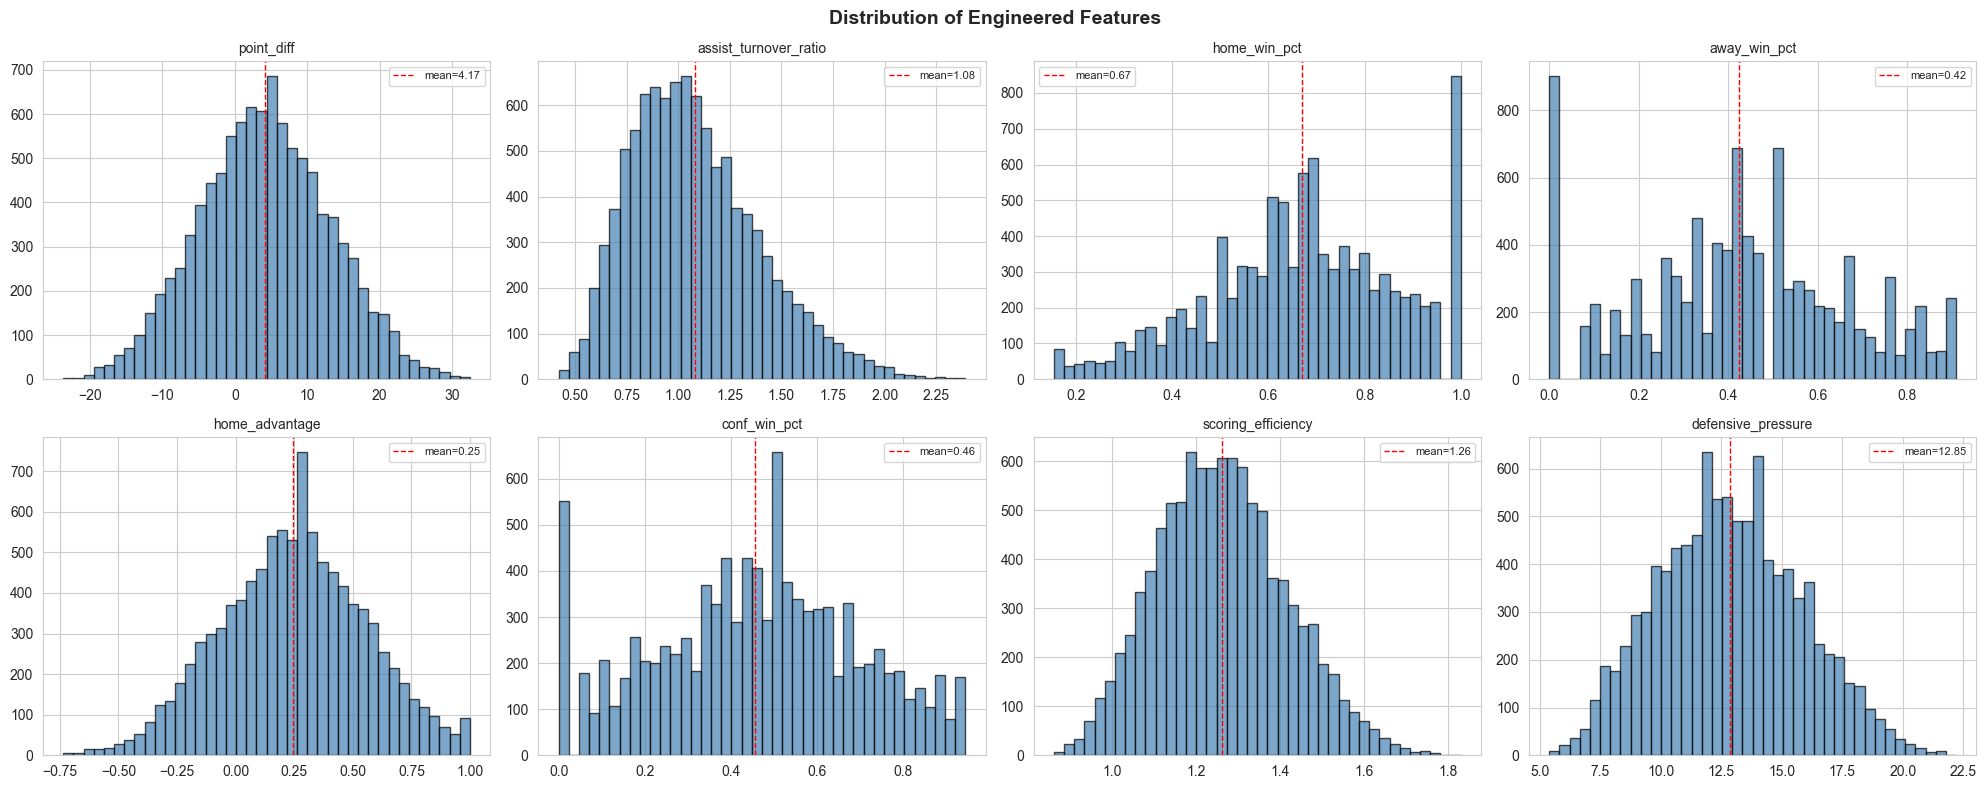

In [5]:
# visualize distributions of new features
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Distribution of Engineered Features', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(new_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f'mean={df[col].mean():.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Save Feature-Engineered Dataset

In [6]:
# overwrite cleaned data with feature-engineered version
df.to_csv("../data/processed/cleaned_basketball_data.csv", index=False)
print(f"Feature-engineered data saved: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nFinal columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Feature-engineered data saved: 10,000 rows x 45 columns

Final columns (45):
   1. id
   2. year
   3. rank
   4. school
   5. games
   6. wins
   7. losses
   8. win_percentage
   9. conference_wins
  10. conference_losses
  11. home_wins
  12. home_losses
  13. away_wins
  14. away_losses
  15. offensive_rating
  16. defensive_rating
  17. net_rating
  18. field_goals
  19. field_goal_attempts
  20. field_goal_percentage
  21. 3_pointers
  22. 3_pointer_attempts
  23. 3_pointer_percentage
  24. effective_field_goal_percentage
  25. free_throws
  26. free_throw_attempts
  27. free_throw_percentage
  28. offensive_rebounds
  29. total_rebounds
  30. assists
  31. steals
  32. blocks
  33. turnovers
  34. personal_fouls
  35. points
  36. opponent_points
  37. simple_rating
  38. point_diff
  39. assist_turnover_ratio
  40. home_win_pct
  41. away_win_pct
  42. home_advantage
  43. conf_win_pct
  44. scoring_efficiency
  45. defensive_pressure
